In [20]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [21]:
def nome (stringa):
    
    stringa_nuova = stringa.replace(f'./Data/dati_','').replace('.csv','')
    return stringa_nuova

In [22]:
input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir(f'./Data'))]
data1 = {}

for input_file in input_files:
    letti = pd.read_csv(input_file)

    data1[nome(input_file)] = {
        "angoli": [np.array(letti["angolo"], dtype=float),
                   np.var(np.array(letti["angolo"], dtype=float))],
        "intensita": [np.array(letti["intensita"], dtype=float),
                      np.var(np.array(letti["intensita"], dtype=float))]
        }

In [24]:
gf.display_dizionario(data1)

[-1766.7958464324095, -11683.80859150553, 28311948.40365275]
[-308.4909308497988, 16692.501449621777, 26727099.496057365]


/tmp/ipykernel_125751/4199701866.py:27: RuntimeWarning: invalid value encountered in sqrt
  (output.beta[2], np.sqrt(output.cov_beta[2][1])))


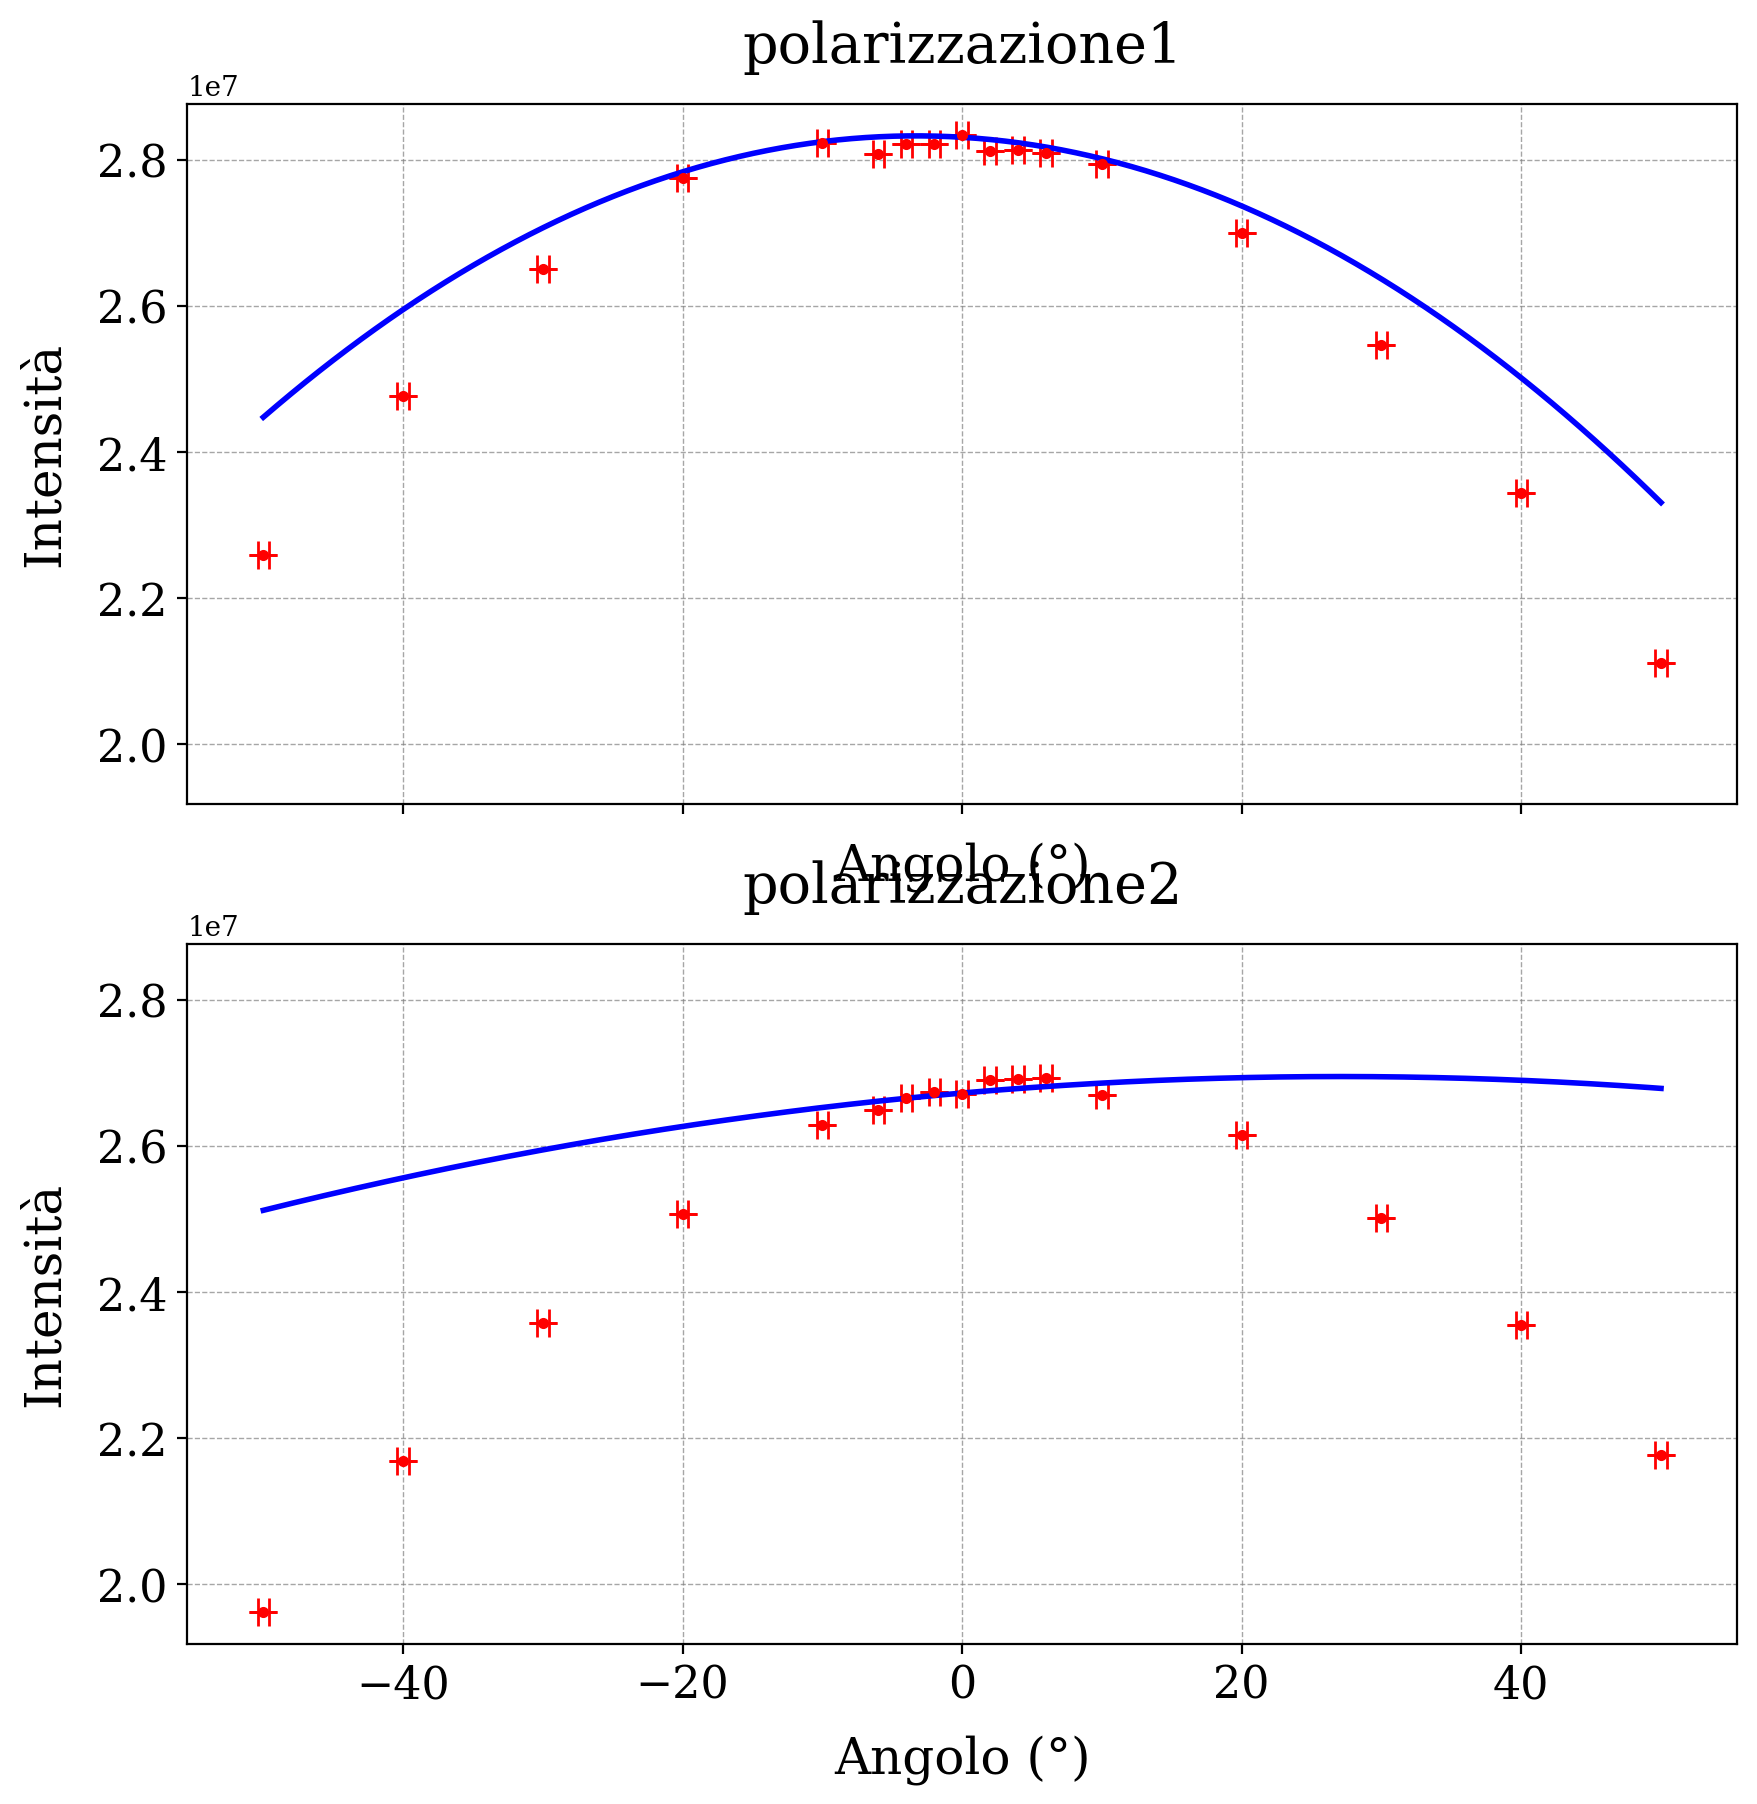

In [26]:
from scipy.odr import Model, RealData, ODR

fig,axes = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5), sharex=True, sharey=True)

for i,(titolo,dati) in enumerate(data1.items()):

    ax = axes[i]

    # Dati
    xdata = [dati["angoli"][0], np.full_like(dati["angoli"][0], 2/np.sqrt(24))]
    ydata = [dati["intensita"][0], np.full_like(dati["intensita"][0], 1/np.sqrt(12))]

    # Grafico dei dati
    gf.parametri_grafico(ax,titolo,xlabel="Angolo (°)",ylabel="Intensità")
    ax.errorbar(xdata[0], ydata[0], xerr=xdata[1], yerr=ydata[1], color="red", fmt=".", **gf.default_error_params())

    # Modello parabolico per fit con ODR
    def parabola(B, x):
        (a, b, c) = B
        return a*x**2 + b*x + c
    model = Model(parabola)
    data = RealData(xdata[0], ydata[0], sx=xdata[1], sy=ydata[1])
    odr = ODR(data, model, beta0=[-1000.0, 0.0, 1.0])
    output = odr.run()
    anal = ((output.beta[0], np.sqrt(output.cov_beta[0][0])),
            (output.beta[1], np.sqrt(output.cov_beta[1][1])),
            (output.beta[2], np.sqrt(output.cov_beta[2][1])))

    # Plot fit
    x = np.linspace(np.min(xdata), np.max(xdata), 500)
    y = parabola([anal[0][0], anal[1][0], anal[2][0]], x)
    ax.plot(x, y, color="blue")

    del xdata,ydata,x,y

    print([anal[0][0], anal[1][0], anal[2][0]])

In [ ]:
"""from scipy.odr import Model, RealData, ODR

fig,ax = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5), sharex=True, sharey=True)

for dati in data1.values():

    # Dati
    xdata = [dati["angoli"], np.full_like(dati["angoli"], 2/np.sqrt(24))]
    ydata = [dati["intensita"], np.full_like(dati["intensita"], 1/np.sqrt(12))]

    # Grafico dei dati
    ax.errorbar(xdata[0], ydata[0], xerr=xdata[1], yerr=ydata[1], color="red", fmt=".", **gf.default_error_params())

    # Modello parabolico per fit con ODR
    def coseno(B, x):
        a = B
        return a**2 * (np.cos(x))**2
    model = Model(coseno)
    data = RealData(xdata[0], ydata[0], sx=xdata[1], sy=ydata[1])
    odr = ODR(data, model, beta0=[1.0])
    output = odr.run()

    anal = (output.beta[0], np.sqrt(output.cov_beta[0][0]))

    # Plot fit
    x = np.linspace(np.min(xdata), np.max(xdata), 500)
    y = parabola(anal[0], x)
    ax.plot(x, y, color="blue")

    del xdata,ydata,x,y

    print(anal[0])
"""

'from scipy.odr import Model, RealData, ODR\n\nfig,ax = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5), sharex=True, sharey=True)\n\nfor dati in data1.values():\n\n    # Dati\n    xdata = [dati["angoli"], np.full_like(dati["angoli"], 2/np.sqrt(24))]\n    ydata = [dati["intensita"], np.full_like(dati["intensita"], 1/np.sqrt(12))]\n\n    # Grafico dei dati\n    ax.errorbar(xdata[0], ydata[0], xerr=xdata[1], yerr=ydata[1], color="red", fmt=".", **gf.default_error_params())\n\n    # Modello parabolico per fit con ODR\n    def coseno(B, x):\n        a = B\n        return a**2 * (np.cos(x))**2\n    model = Model(coseno)\n    data = RealData(xdata[0], ydata[0], sx=xdata[1], sy=ydata[1])\n    odr = ODR(data, model, beta0=[1.0])\n    output = odr.run()\n\n    anal = (output.beta[0], np.sqrt(output.cov_beta[0][0]))\n\n    # Plot fit\n    x = np.linspace(np.min(xdata), np.max(xdata), 500)\n    y = parabola(anal[0], x)\n    ax.plot(x, y, color="blue")\n\n    del xdata,ydata,x,y